In [1]:
import pandas as pd
import numpy as np
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:
zip_file = "house-prices-advanced-regression-techniques.zip"


with zipfile.ZipFile(zip_file, 'r') as z:
    train_data = pd.read_csv(z.open('train.csv'))

train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
X = train_data[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = train_data['SalePrice']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (1460, 3)
Target Shape: (1460,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1168, 3)
Testing Data: (292, 3)


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Training Completed!")

Model Training Completed!


In [8]:
print("Intercept:", model.intercept_)
print("\nCoefficients:")
feature_names = X.columns
for feature, coef in zip(feature_names, model.coef_):
    print(f"{feature}: {coef}")

Intercept: 52261.748626944594

Coefficients:
GrLivArea: 104.0263070122644
BedroomAbvGr: -26655.165357341266
FullBath: 30014.324108956615


In [9]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004 121157.48079629 205577.98056584 183787.20378269
 121157.48079629 147219.22233196]


In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Model Evaluation")
print("-"*30)
print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,4))

Model Evaluation
------------------------------
MAE : 35788.06
MSE : 2806426667.25
RMSE: 52975.72
R² Score: 0.6341


In [11]:
new_house = [[2000, 3, 2]]
predicted_price = model.predict(new_house)
print("Predicted House Price: $", round(predicted_price[0],2))

Predicted House Price: $ 240377.51


C:\Users\mahek\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,154500,113410.672553
1,325000,305081.877759
2,115000,135904.785630
3,159000,205424.675641
4,315500,227502.683490
5,75500,121157.480796
6,311500,205577.980566
7,146000,183787.203783
8,84500,121157.480796
9,135500,147219.222332


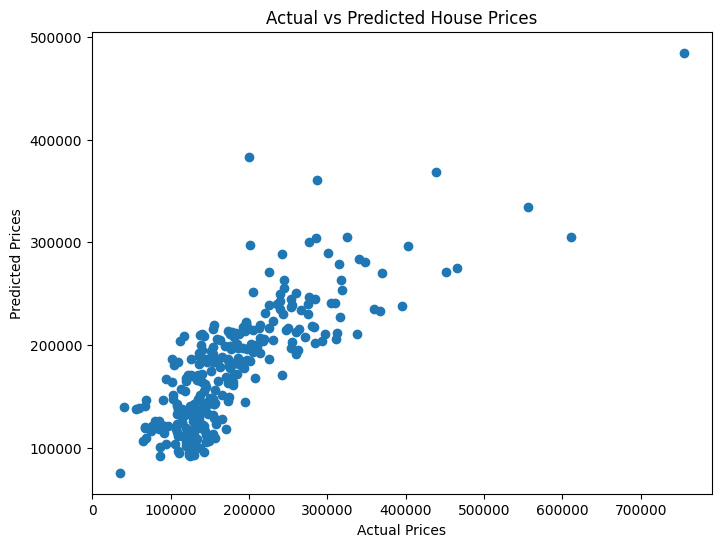

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()